# Imports and Data Loading

In [80]:
import pandas as pd
import numpy as np

import math
import random

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette("flare")

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

np.random.seed(42)
random.seed(42)

In [81]:
df = pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [82]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

# Data Exploration and Cleaning

## Data Dictionary

The next table shows the data dictionary (features explaination).

<div style="
    max-width: 1200px;
    margin: 0 60px;
    padding: 30px;
    background: linear-gradient(145deg, #1e1e1e, #252526);
    border-radius: 18px;
    box-shadow: 0 0 30px rgba(0,0,0,0.6);
    overflow-x: auto;
    font-family: 'Segoe UI', sans-serif;
">

<h2 style="
    color:#4FC3F7;
    text-align:center;
    letter-spacing:1px;
    margin-bottom:30px;
    font-weight:500;
">
Credit Card Dataset – Data Dictionary
</h2>

<center><p>You can see the full version with example in the repository's README file on Github or In Data Dictionary.xlsx file.</p></center>
<br>
<table style="
    width:100%;
    border-collapse: collapse;
    color:#E0E0E0;
    font-size:12px;
    line-height:1.4;
">

<thead>
<tr style="
    background-color:#2d2d2d;
    color:#81D4FA;
    text-transform:uppercase;
    font-size:11px;
    letter-spacing:0.5px;
">
<th style="padding:12px;">Feature Name</th>
<th style="padding:12px;">Short Description</th>
<th style="padding:12px;">Long Description</th>
<th style="padding:12px;">Effects (Insights)</th>
</tr>
</thead>

<tbody>

<tbody>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">CUST_ID</b></td>
<td>Identification of Credit Card holder (Categorical)</td>
<td>Unique ID for each customer.</td>
<td>No effect</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">BALANCE</b></td>
<td>Balance amount left in their account to make purchases (</td>
<td>Remaining unpaid amount on the credit card <br>(This is how much the customer still owes the bank)</td>
<td>High BALANCE → customer carries debt <br>Low BALANCE → customer pays quickly</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">BALANCE_FREQUENCY</b></td>
<td>How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)</td>
<td>How often balance is updated. (Shows activity consistency)</td>
<td>1 → Updated every month (active user) <br>0 → Rarely updated (inactive card)</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">PURCHASES</b></td>
<td>Amount of purchases made from account</td>
<td>Total amount spent using card.</td>
<td>Measures spending power and consumption level</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">ONEOFF_PURCHASES</b></td>
<td>Maximum purchase amount done in one-go</td>
<td>Largest amount spent in a single transaction</td>
<td>High value → customer makes big purchases (travel,exp) <br>Low value → everyday spending</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">INSTALLMENTS_PURCHASES</b></td>
<td>Amount of purchase done in installment</td>
<td>Total amount bought using installment plans.</td>
<td>Shows how much customer prefer to pay in installments</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">CASH_ADVANCE</b></td>
<td>Cash in advance given by the user</td>
<td>Money withdrawn as cash using credit card. (RISKY)</td>
<td>High cash advance → financially stressed customer <br>Bank charges high interest here</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">PURCHASES_FREQUENCY</b></td>
<td>How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)</td>
<td>How often purchases are made.</td>
<td>1 → Frequent shopping <br>0 → Rare usage</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">ONEOFFPURCHASESFREQUENCY</b></td>
<td>How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)</td>
<td>How often large single purchases happen.</td>
<td>If customer buys big electronics often → high score.</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">PURCHASESINSTALLMENTSFREQUENCY</b></td>
<td>How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)</td>
<td>How often installment purchases occur.</td>
<td>High → customer regularly buys on EMI <br>Low → rarely uses installment option</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">CASHADVANCEFREQUENCY</b></td>
<td>How frequently the cash in advance being paid</td>
<td>How often customer withdraws cash from credit card.</td>
<td>High frequency = risky client.</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">CASHADVANCETRX</b></td>
<td>Number of Transactions made with "Cash in Advanced"</td>
<td>Number of cash advance transactions.</td>
<td>EG: 3 ATM withdrawals</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">PURCHASES_TRX</b></td>
<td>Numbe of purchase transactions made</td>
<td>Number of purchase transactions.</td>
<td>Customer A: $2000 in 2 transactions (big spender) <br>Customer B: $2000 in 100 transactions (frequent shopper)</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">CREDIT_LIMIT</b></td>
<td>Limit of Credit Card for user</td>
<td>Maximum allowed borrowing limit.</td>
<td>High credit limit → trusted customer</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">PAYMENTS</b></td>
<td>Amount of Payment done by user</td>
<td>Total amount paid by customer.</td>
<td>If customer paid $1800 during year → PAYMENTS = 1800</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">MINIMUM_PAYMENTS</b></td>
<td>Minimum amount of payments made by user</td>
<td>Minimum required payment paid.</td>
<td>If bill = $1000, Minimum due = $50 <br>If customer pays only $50 → financially weak behavior.</td>
</tr>

<tr style="border-bottom:1px solid #333;">
<td><b style="color:#4FC3F7;">PRCFULLPAYMENT</b></td>
<td>Percent of full payment paid by user</td>
<td>Percentage of months where full balance was paid.</td>
<td>High PRCFULLPAYMENT → responsible <br>Low → revolver (bank earns interest)</td>
</tr>

<tr style="background-color:#222;">
<td><b style="color:#4FC3F7;">TENURE</b></td>
<td>Tenure of credit card service for user</td>
<td>Number of months/years customer has had the credit card.</td>
<td>Long tenure → loyal customer <br>Short tenure → new client</td>
</tr>

</tbody>
</table>
<br>
<center><p>The data dictionary is researched by human: Ahmed Gamal. The styling/formatting is made by AI: <a href="https://chatgpt.com/share/698fab3c-6994-8009-b573-5b6a67bbcca8">ChatGPT</p></center>

</div>


## General Exploration

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

Total rows are 8950 but found some nulls

In [84]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


Possible outliers in most of continous columns (big differences between Q3 and Max)

Consistent values in all frequencies columns except CASH_ADVANCE_FREQUENCY feature with max of 1.5

Possible data cutoff in the Tenure column

Will see all of them in the plots 

## Checking for duplicates

In [85]:
df[df.duplicated()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


No duplicates found

Next, I will check if there is customer that is shown more than once in my dataset

In [86]:
df[df.duplicated(subset = ['CUST_ID'], keep = False)]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


No repeated customers in the dataset

Next, making sure that all of the rows are also unique without the CUST_ID column

In [87]:
df.drop(columns=["CUST_ID"], axis=1)[df.drop(columns=["CUST_ID"], axis=1).duplicated()]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


Made sure that no duplicates in data

## Checking for missing data

In [88]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

CREDIT_LIMIT and MINIMUM_PAYMENTS columns have missing data

CREDIT LIMIT has only 1 missing value, dropping will not make so much problem

MINIMUM_PAYMENTS has 313 out of 8950 row, checking for ways to impute them

In [89]:
missing_credit_rows = df[df['CREDIT_LIMIT'].isna()]
missing_credit_rows

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,C15349,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


In [90]:
missing_minimum_payments = df[df['MINIMUM_PAYMENTS'].isna()]
missing_minimum_payments

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,C10056,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8919,C19160,14.524779,0.333333,152.00,152.00,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,1500.0,0.000000,NaN,0.0,6
8929,C19170,371.527312,0.333333,0.00,0.00,0.0,1465.407927,0.000000,0.000000,0.000000,0.166667,5,0,1500.0,0.000000,NaN,0.0,6
8935,C19176,183.817004,1.000000,465.90,0.00,465.9,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,0.000000,NaN,0.0,6
8944,C19185,193.571722,0.833333,1012.73,1012.73,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,4000.0,0.000000,NaN,0.0,6


I have decided to use Iterative Imputer from sklearn to create a regression model that will predict the missing values

In [91]:
nans_imputer = IterativeImputer(random_state=42)
df_numerical_cols = df.select_dtypes(include=[np.number])

nans_imputer.fit(df_numerical_cols)  # learn relationships between numerical features

X = nans_imputer.transform(df_numerical_cols)  # replace missing values iteratively

Created the imputer

I will check for the distributions of them before imputing to make sure that imputing didn't change the distribution

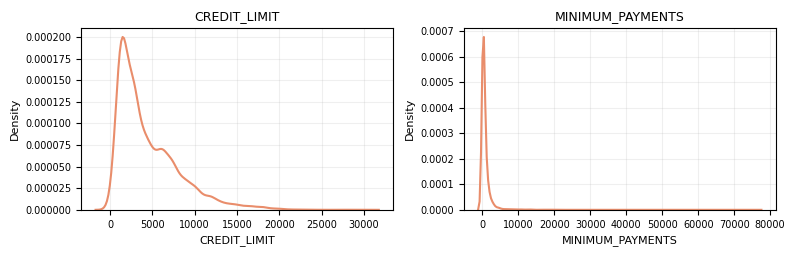

In [92]:
plt.rcParams.update({"font.size": 8})
fig, axes = plt.subplots(1, 2, figsize=(4*2, 2.6))
axes = np.array(axes).ravel()

for i, col in enumerate(["CREDIT_LIMIT","MINIMUM_PAYMENTS"]):
    ax = axes[i]
    sns.kdeplot(df[col], ax=ax)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

In [93]:
df = pd.DataFrame(
    X,
    columns=df_numerical_cols.columns,
    index=df_numerical_cols.index
)
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,431.220627,0.000000,12.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


Dropped the CUST_ID column as it's not useful

Replaced nulls using the regressor imputer

In [94]:
df.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

No missing are now in the data

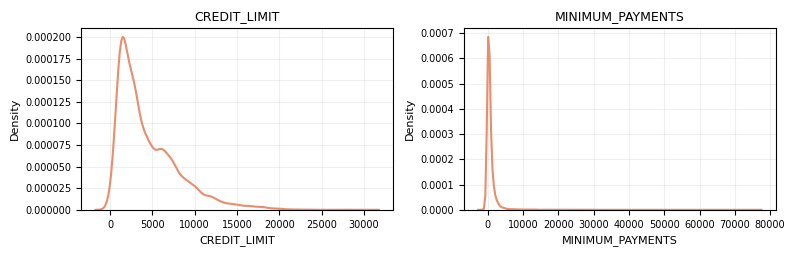

In [95]:
plt.rcParams.update({"font.size": 8})
fig, axes = plt.subplots(1, 2, figsize=(4*2, 2.6))
axes = np.array(axes).ravel()

for i, col in enumerate(["CREDIT_LIMIT","MINIMUM_PAYMENTS"]):
    ax = axes[i]
    sns.kdeplot(df[col], ax=ax)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

Rechecked the columns and distributions are the same

## Checking for inconsistencies

Possible inconsistency exist in the CASH_ADVANCE_FREQUENCY as it has maximum of 1.5 different from the other frequency columns

In [96]:
df[df["CASH_ADVANCE_FREQUENCY"]>1].sort_values(by="CASH_ADVANCE_FREQUENCY")

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8055,1917.895730,1.000000,285.07,285.07,0.0,6084.858872,0.363636,0.363636,0.0,1.090909,28.0,6.0,3000.0,5692.682993,556.449635,0.0,11.0
2608,7801.511533,1.000000,231.40,231.40,0.0,4109.465221,0.100000,0.100000,0.0,1.100000,20.0,3.0,13500.0,1593.617739,1522.496755,0.0,10.0
2555,5906.184924,1.000000,141.80,141.80,0.0,1651.286918,0.125000,0.125000,0.0,1.125000,12.0,2.0,10000.0,933.969974,919.289675,0.0,8.0
8365,3857.562230,1.000000,0.00,0.00,0.0,2127.213754,0.000000,0.000000,0.0,1.142857,26.0,0.0,5000.0,617.508991,538.396872,0.0,7.0
3253,5709.486507,0.833333,0.00,0.00,0.0,2794.326341,0.000000,0.000000,0.0,1.166667,10.0,0.0,6000.0,550.513331,1299.463370,0.0,6.0
1626,2876.009336,1.000000,152.61,152.61,0.0,3719.650168,0.333333,0.333333,0.0,1.166667,24.0,2.0,4000.0,248.342971,584.926336,0.0,6.0
681,5656.069801,1.000000,362.36,362.36,0.0,7240.433194,0.250000,0.250000,0.0,1.250000,12.0,2.0,8000.0,683.421497,2036.877611,0.0,8.0
3038,3846.742530,1.000000,0.00,0.00,0.0,1932.460679,0.000000,0.000000,0.0,1.500000,18.0,0.0,5600.0,496.245836,538.346874,0.0,6.0


Number of rows that have CASH_ADVANCE_FREQUENCY > 1

Maybe they are mistakes as I checked for the columns related to cash advance and there is nothing that may have caused the overshooting in the frequency

I decided to make all of them 1

In [97]:
df[["CASH_ADVANCE_FREQUENCY"]] = df[["CASH_ADVANCE_FREQUENCY"]].clip(upper=1)

In [98]:
df[df["CASH_ADVANCE_FREQUENCY"]>1].sort_values(by="CASH_ADVANCE_FREQUENCY")

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


In [99]:
df["CASH_ADVANCE_FREQUENCY"].describe()

count    8950.000000
mean        0.134972
std         0.199257
min         0.000000
25%         0.000000
50%         0.000000
75%         0.222222
max         1.000000
Name: CASH_ADVANCE_FREQUENCY, dtype: float64

# Data Visualization

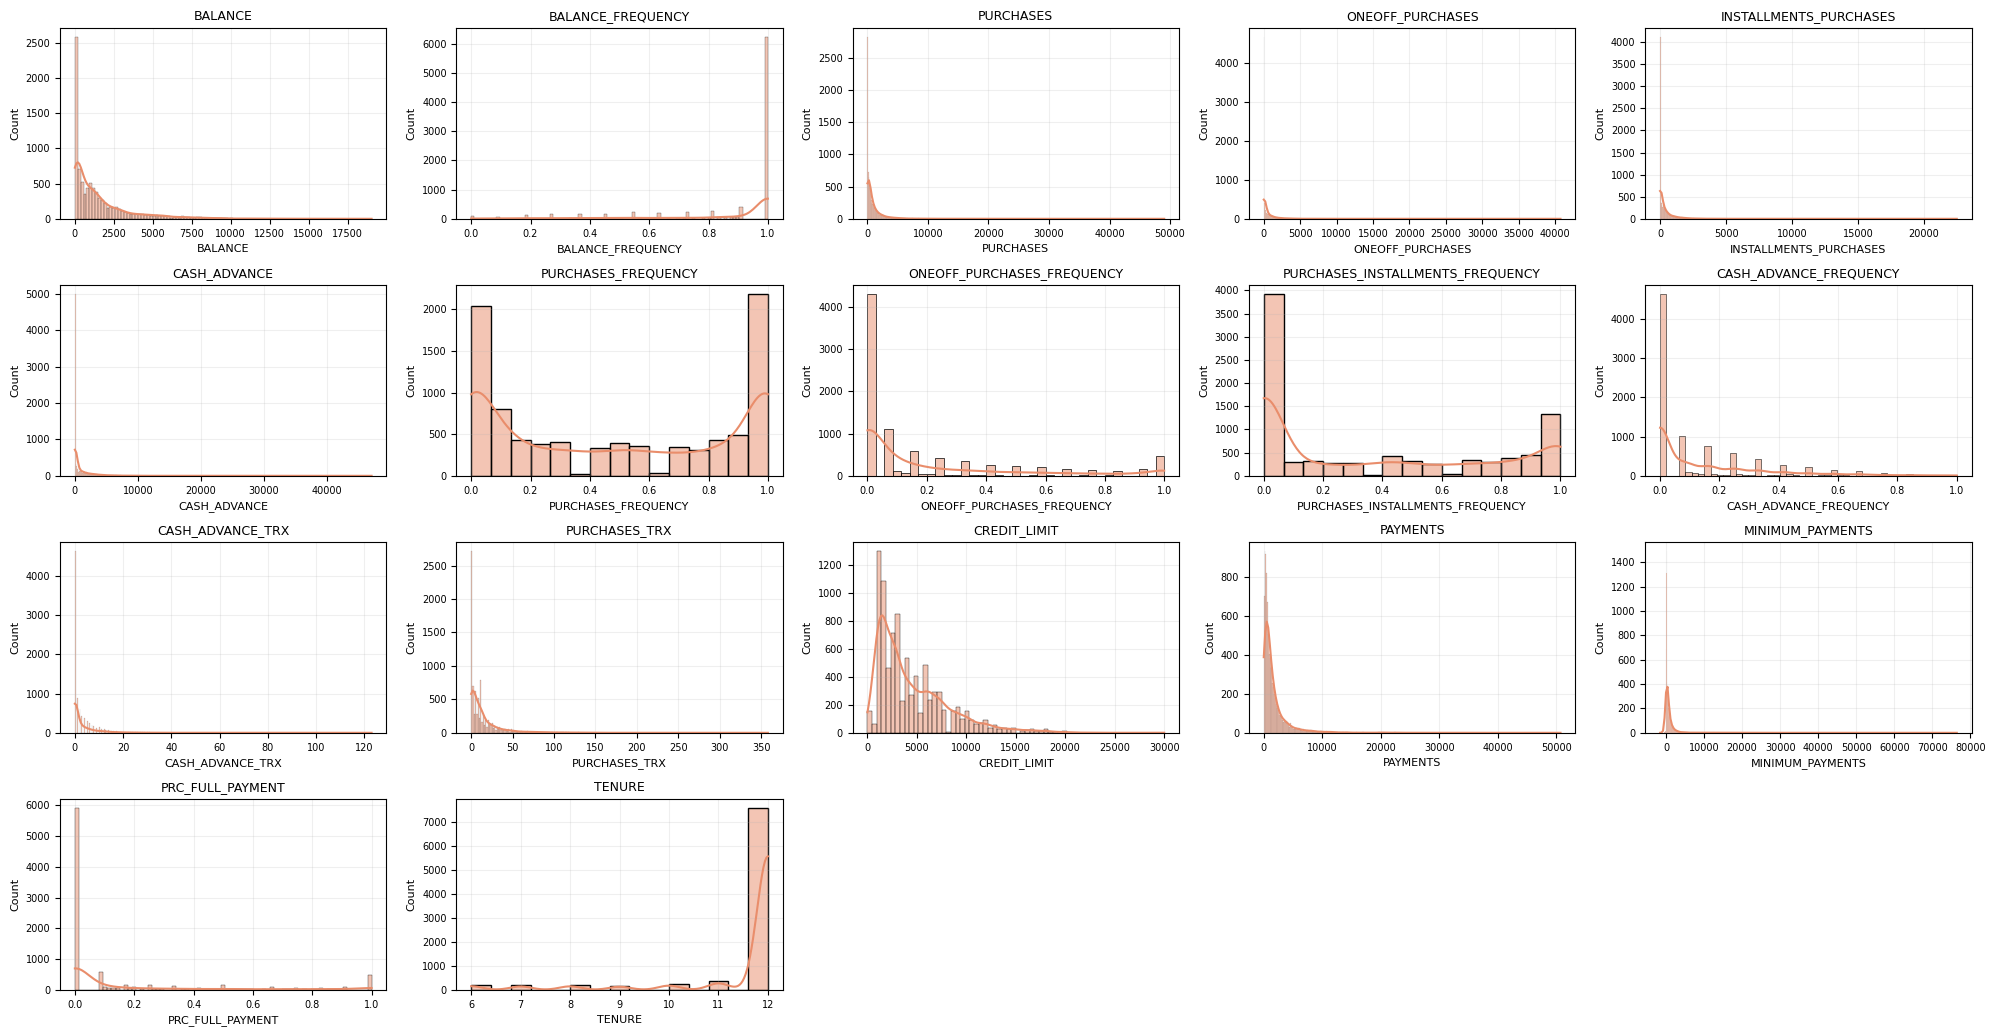

In [100]:
num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)

ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

plt.rcParams.update({"font.size": 8})
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.6*nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df[col], bins="auto", kde=True, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

Tried to see the distributions for the features

Most of the distributions are skewed either to left or right (most of them right skewed)

PURCHASES_FREQUENCY and PURCHASES_INSTALLMENTS_FREQUENCY columns show bimodal distributions (may indicate 2 clusters)

Bins are not showing the KDE properly so i will remove them to better see the distributions without bins

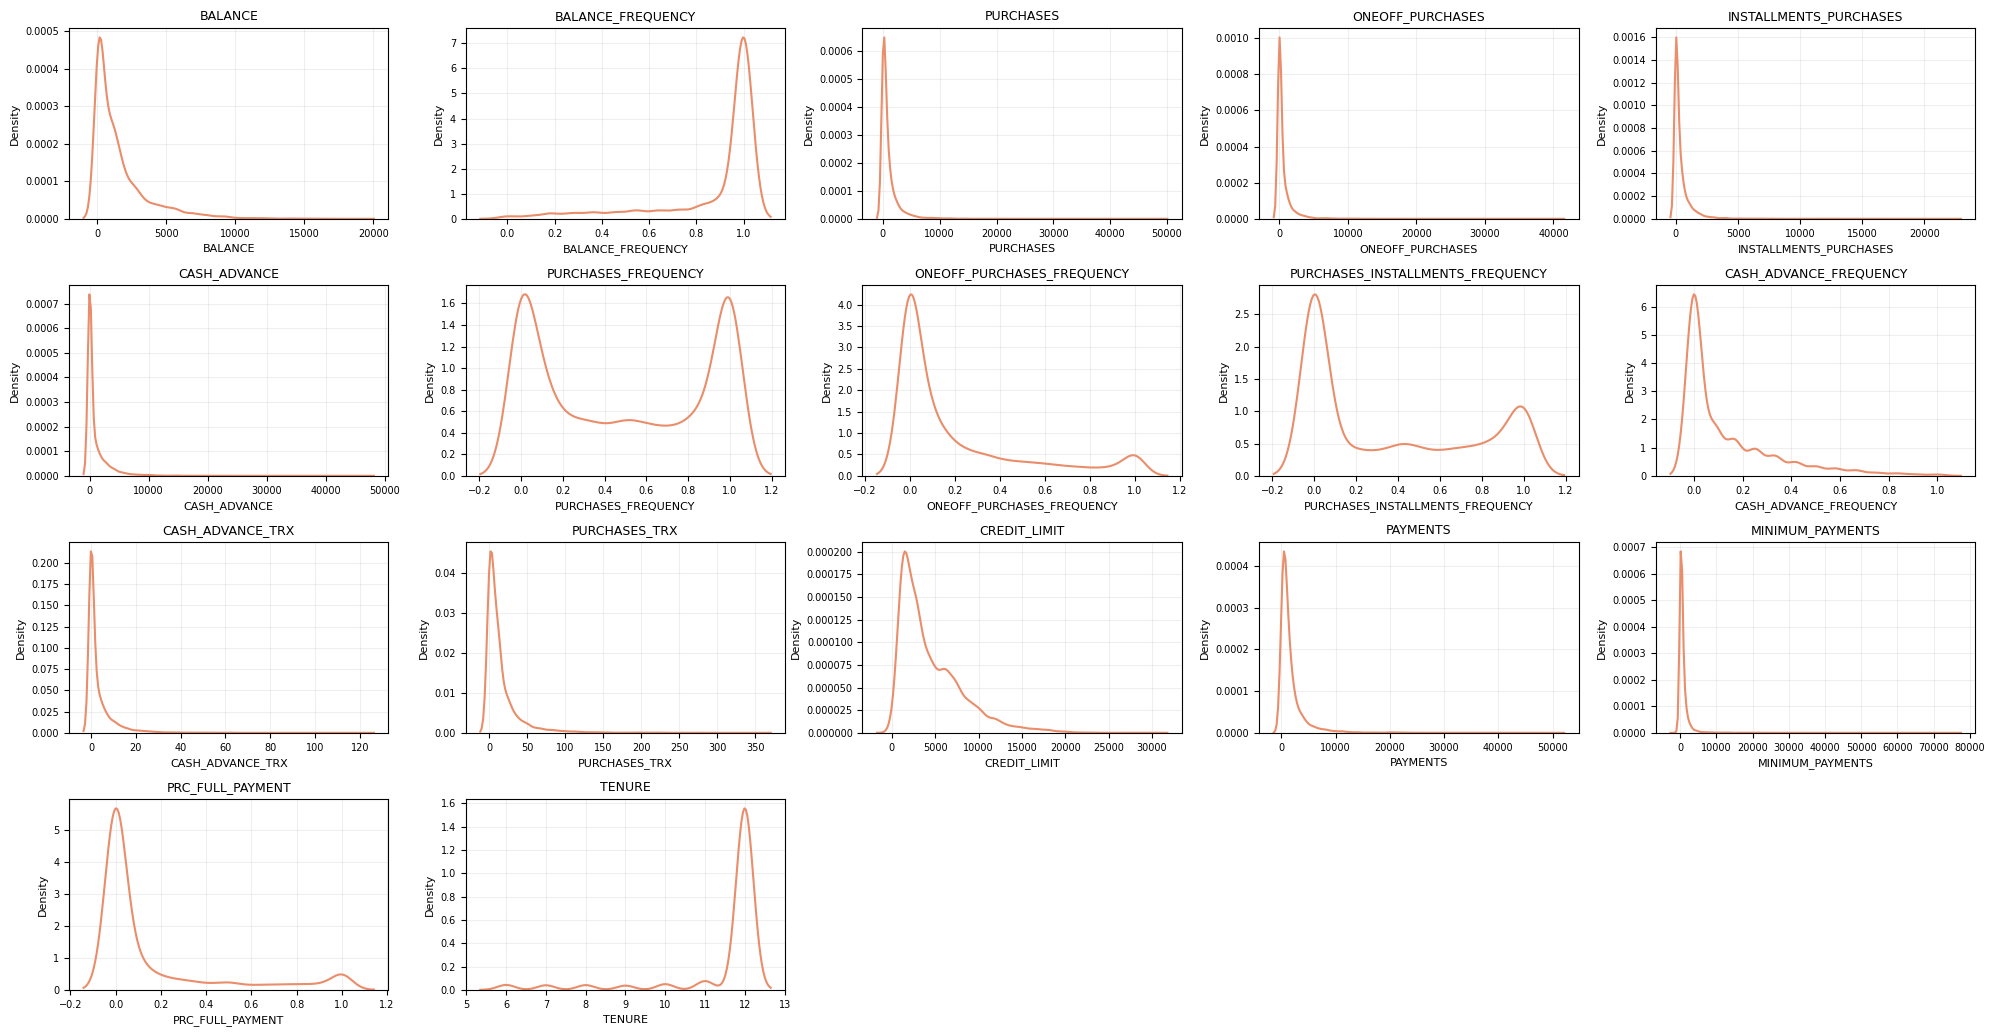

In [101]:
num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)

ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

plt.rcParams.update({"font.size": 8})
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.6*nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.kdeplot(df[col], ax=ax)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

Distributions are now clearer

New Bimodal distribution showed in the ONEOFF_PURCHASES_FREQUENCY column

Possible clusters: 

Based on PURCHASES_FREQUENCY: Customer who do alot of purchases and Customers who don't

Based on PURCHASES_INSTALLMENTS_FREQUENCY: Customer who prefer installments and Customers who don't

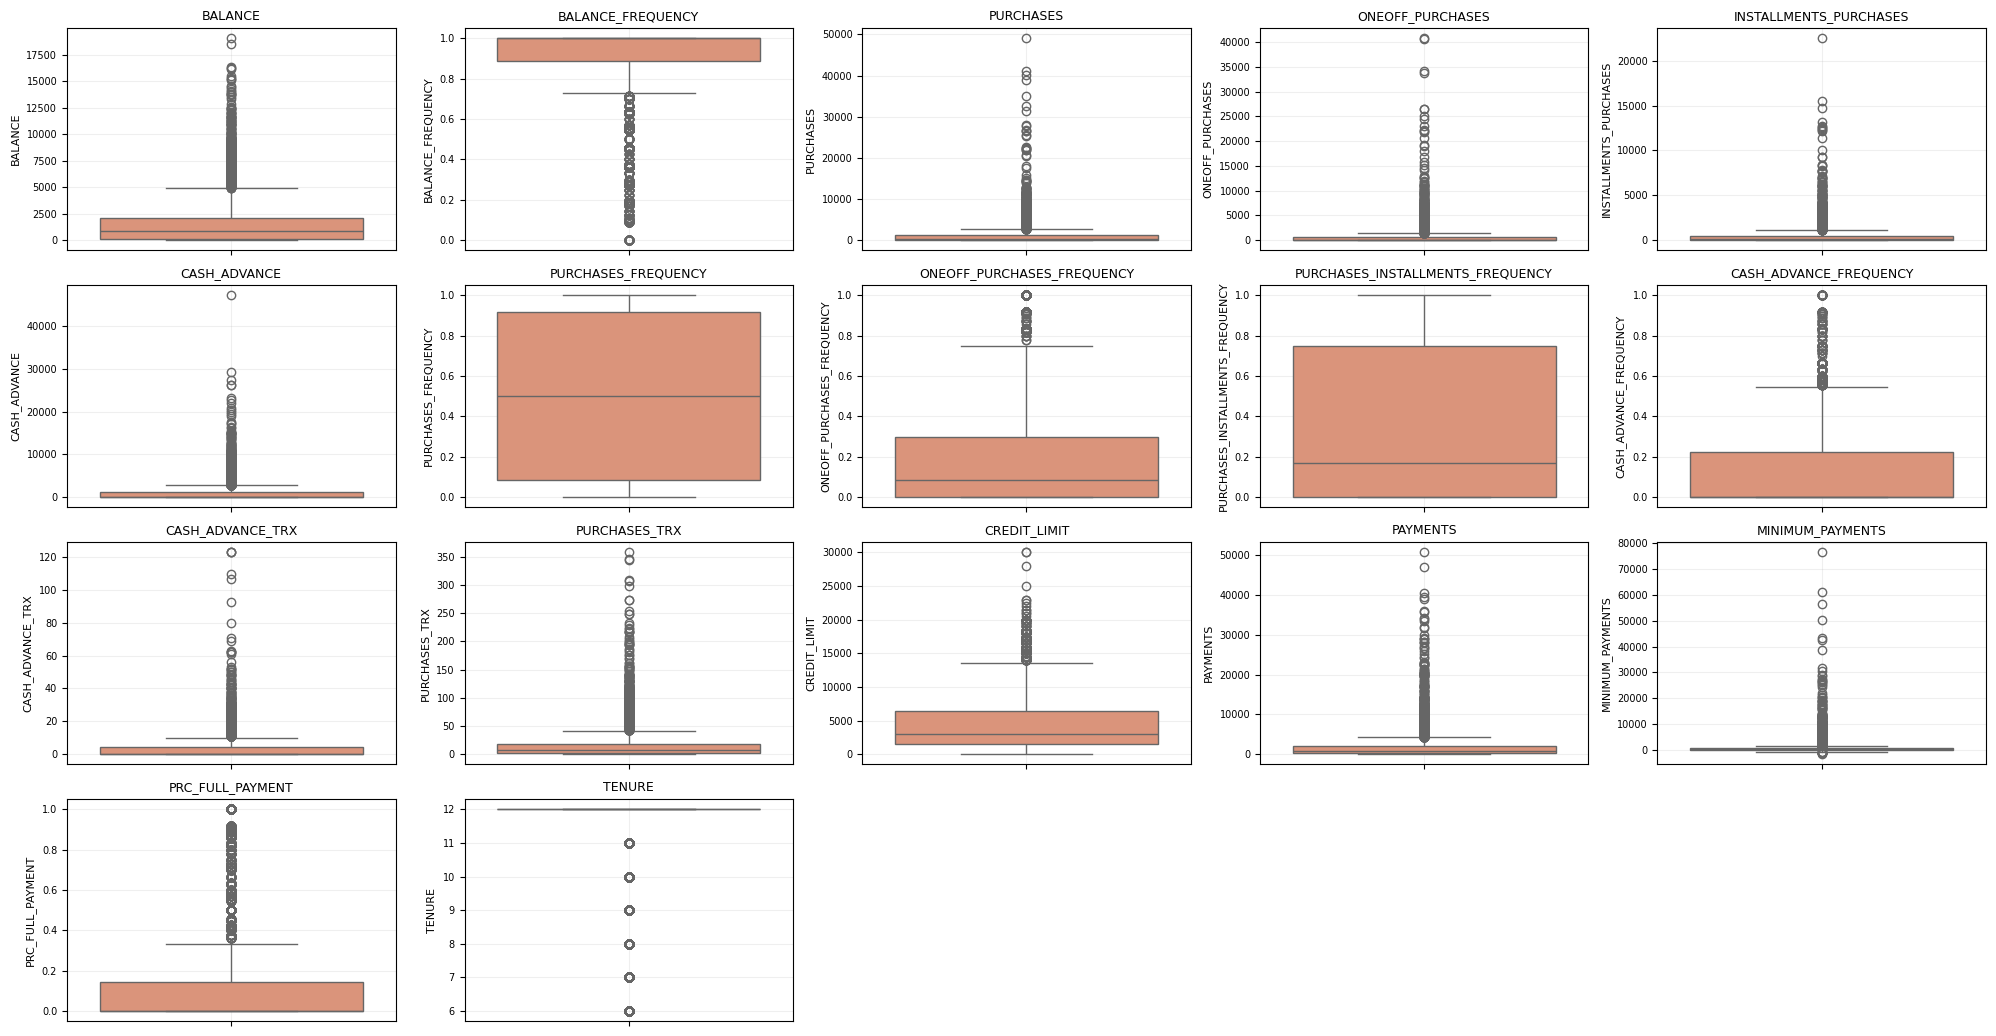

In [104]:
num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)

ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

plt.rcParams.update({"font.size": 8})
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.6*nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(df[col], ax=ax)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")



fig.tight_layout()
plt.show()

Clearly that TENURE has cutoff at value of 12

Possible outliers in PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE

Should be checked and ensure if they are normal
